# Bayesian SV Simulation

This notebook illustrates Bayesian inference for a stochastic volatility model using simulated data. The data are generated from a simple stochastic volatility model, so the true latent log-volatility path is known.

The stochastic volatility parameters are kept fixed at their data-generating values. The only unknown object recovered with MCMC is the latent volatility path $h_{1:T}$.

## Imports and Reproducibility

The random seeds match the standalone script: seed `123` for data simulation and seed `456` for the MCMC sampler.

In [1]:
import csv
import os
from pathlib import Path

import numpy as np

SEED_SIMULATION = 123
SEED_MCMC = 456
np.random.seed(SEED_SIMULATION)

# Make the notebook robust whether it is run from the project root or this directory.
cwd = Path.cwd()
if cwd.name == 'appendix_simulation':
    APPENDIX_DIR = cwd
elif (cwd / 'appendix_simulation').exists():
    APPENDIX_DIR = cwd / 'appendix_simulation'
else:
    APPENDIX_DIR = cwd

FIGURE_DIR = APPENDIX_DIR / 'figures'
OUTPUT_DIR = APPENDIX_DIR / 'output'
MPL_CACHE_DIR = APPENDIX_DIR / '.matplotlib-cache'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib.pyplot as plt
from IPython.display import display


## Model Specification

The simulated stochastic volatility model is

$$
r_t = \exp(h_t / 2)\epsilon_t, \qquad \epsilon_t \sim N(0, 1),
$$

$$
h_t = \mu + \phi(h_{t-1} - \mu) + \sigma_\eta \eta_t, \qquad \eta_t \sim N(0, 1).
$$

$r_t$ denotes the observed return, while $h_t$ is the latent log-volatility. The parameter $\mu$ controls the long-run mean of log-volatility, $\phi$ controls persistence, and $\sigma_eta$ controls the innovation scale of the latent volatility process.

## Parameter Values

The following parameters are fixed throughout the notebook. They are used both to generate the data and to define the posterior distribution for the latent path.

In [2]:
T = 1000
mu = -10.0
phi = 0.98
sigma_eta = 0.20
N_ITER = 12000
BURN_IN = 4000
PROPOSAL_SD = 0.15

settings_summary = [
    ('T', T),
    ('mu', mu),
    ('phi', phi),
    ('sigma_eta', sigma_eta),
    ('MCMC iterations', N_ITER),
    ('burn-in', BURN_IN),
    ('proposal standard deviation', PROPOSAL_SD),
]

print('Fixed SV parameters and MCMC settings:')
print(f"{'Quantity':<30}Value")
print('-' * 42)
for name, value in settings_summary:
    print(f'{name:<30}{value}')

Fixed SV parameters and MCMC settings:
Quantity                      Value
------------------------------------------
T                             1000
mu                            -10.0
phi                           0.98
sigma_eta                     0.2
MCMC iterations               12000
burn-in                       4000
proposal standard deviation   0.15


## Data Simulation

The initial latent state is drawn from the stationary distribution of the AR(1) process. Returns are then simulated from a conditionally Gaussian observation equation with variance $exp(h_t)$.

In [3]:
def simulate_sv(T=1000, mu=-10.0, phi=0.98, sigma_eta=0.20, seed=123):
    """Simulate a basic stochastic volatility model without using pandas."""
    rng = np.random.default_rng(seed)
    h = np.empty(T)

    # Stationary initialization for the latent AR(1) process.
    stationary_sd = sigma_eta / np.sqrt(1.0 - phi**2)
    h[0] = rng.normal(mu, stationary_sd)

    for t in range(1, T):
        h[t] = mu + phi * (h[t - 1] - mu) + sigma_eta * rng.normal()

    returns = np.exp(h / 2.0) * rng.normal(size=T)

    data = {
        'time': np.arange(1, T + 1),
        'h_true': h,
        'vol_true': np.exp(h / 2.0),
        'return': returns,
        'abs_return': np.abs(returns),
    }
    params = {'T': T, 'mu': mu, 'phi': phi, 'sigma_eta': sigma_eta, 'seed': seed}
    return data, params


data, params = simulate_sv(T=T, mu=mu, phi=phi, sigma_eta=sigma_eta, seed=SEED_SIMULATION)

print('First five simulated observations:')
print('time      h_true        return    abs_return')
for i in range(5):
    print(
        f"{data['time'][i]:4d}  "
        f"{data['h_true'][i]:10.4f}  "
        f"{data['return'][i]:12.6f}  "
        f"{data['abs_return'][i]:10.6f}"
    )

First five simulated observations:
time      h_true        return    abs_return
   1    -10.9941      0.004644    0.004644
   2    -11.0478     -0.006832    0.006832
   3    -10.7692      0.000887    0.000887
   4    -10.7151      0.003722    0.003722
   5    -10.5167      0.005370    0.005370


## Simulation Plots

The next figures show the simulated latent log-volatility, simulated returns, and absolute returns.

In [4]:
plt.rcParams.update(
    {
        'figure.figsize': (8.0, 4.2),
        'font.size': 11,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'legend.fontsize': 10,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.25,
        'grid.linewidth': 0.6,
        'lines.linewidth': 1.2,
    }
)


def save_and_show(fig, stem):
    """Save a Matplotlib figure as PDF and PNG, then display it inline."""
    pdf_path = FIGURE_DIR / f'{stem}.pdf'
    png_path = FIGURE_DIR / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=300)
    display(fig)
    plt.close(fig)
    return [pdf_path, png_path]

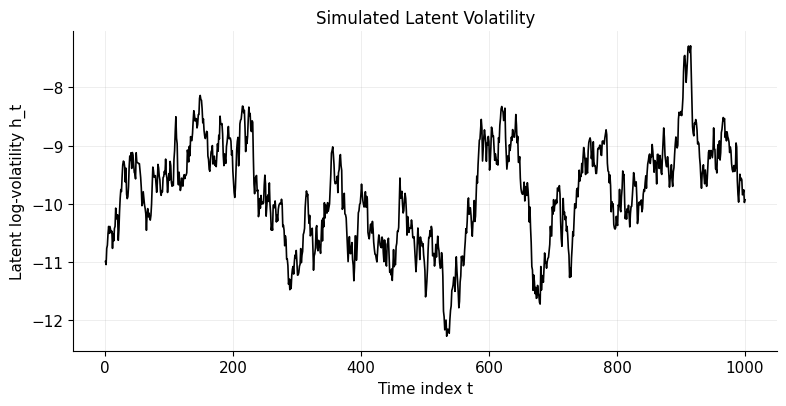

In [5]:
figure_files = []

fig, ax = plt.subplots()
ax.plot(data['time'], data['h_true'], color='black')
ax.set_title('Simulated Latent Volatility')
ax.set_xlabel('Time index t')
ax.set_ylabel('Latent log-volatility h_t')
figure_files.extend(save_and_show(fig, 'fig_A1_latent_volatility'))

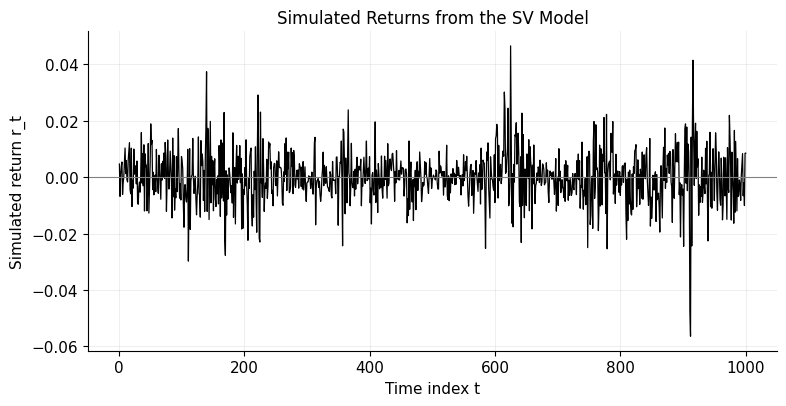

In [6]:
fig, ax = plt.subplots()
ax.plot(data['time'], data['return'], color='black', linewidth=0.9)
ax.axhline(0.0, color='gray', linewidth=0.8)
ax.set_title('Simulated Returns from the SV Model')
ax.set_xlabel('Time index t')
ax.set_ylabel('Simulated return r_t')
figure_files.extend(save_and_show(fig, 'fig_A2_simulated_returns'))

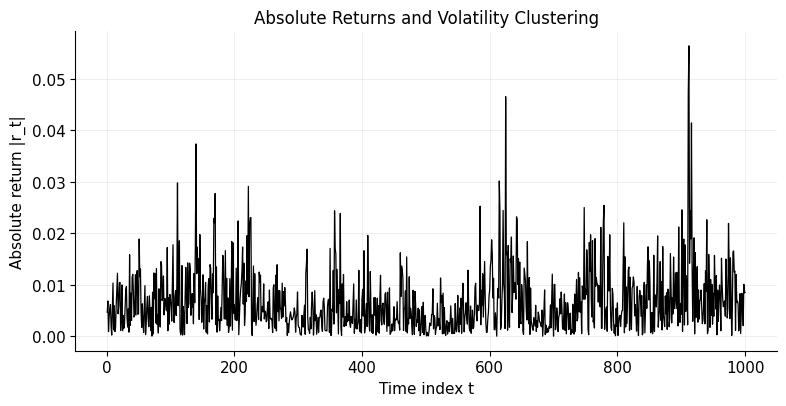

In [7]:
fig, ax = plt.subplots()
ax.plot(data['time'], data['abs_return'], color='black', linewidth=0.9)
ax.set_title('Absolute Returns and Volatility Clustering')
ax.set_xlabel('Time index t')
ax.set_ylabel('Absolute return |r_t|')
figure_files.extend(save_and_show(fig, 'fig_A3_absolute_returns'))

## Fixed-Parameter Inference

The parameters are fixed at their data-generating values. Therefore, the simulation focuses only on posterior recovery of the latent volatility path, not on full parameter estimation.

## MCMC Setup

The posterior target is the latent path conditional on fixed parameters:

$$
p(h_{1:T} \mid r_{1:T}, \mu, \phi, \sigma_\eta).
$$

The sampler is a component-wise random-walk Metropolis-Hastings algorithm. At each sweep, every latent state `h_t` is proposed one at a time from a Gaussian random walk. The parameters `mu`, `phi`, and `sigma_eta` are not estimated.

Settings used below:

- Number of MCMC iterations: `12000`
- Burn-in: `4000`
- Proposal standard deviation: `0.15`
- Selected states for diagnostics: `h_250`, `h_500`, and `h_750`

### Component-wise Metropolis-Hastings Algorithm

1. Initialize the latent path `h` using a simple transformation of squared returns.
2. For each MCMC iteration, sweep through the latent states.
3. For each time index `t`, propose a new value `h_t*` from a Gaussian random walk.
4. Compute the Metropolis-Hastings acceptance probability from the local posterior contribution.
5. Accept or reject the proposed value.
6. After burn-in, store the full latent path draw.

In [8]:
def local_log_posterior(h_value, t, h_path, returns_sq, mu, phi, sigma2, stationary_var):
    """Terms in the log posterior that depend on one latent state h_t."""
    log_density = -0.5 * (h_value + returns_sq[t] * np.exp(-h_value))

    if t == 0:
        log_density += -0.5 * (h_value - mu) ** 2 / stationary_var
    else:
        mean_t = mu + phi * (h_path[t - 1] - mu)
        log_density += -0.5 * (h_value - mean_t) ** 2 / sigma2

    if t < len(h_path) - 1:
        mean_next = mu + phi * (h_value - mu)
        log_density += -0.5 * (h_path[t + 1] - mean_next) ** 2 / sigma2

    return log_density


def mcmc_latent_sv(
    returns,
    mu,
    phi,
    sigma_eta,
    n_iter=N_ITER,
    burn_in=BURN_IN,
    proposal_sd=PROPOSAL_SD,
    seed=456,
    selected_indices=None,
):
    """Component-wise Metropolis-Hastings sampler for the latent SV path."""
    if burn_in >= n_iter:
        raise ValueError('burn_in must be smaller than n_iter.')

    rng = np.random.default_rng(seed)
    returns = np.asarray(returns, dtype=float)
    T = len(returns)
    n_saved = n_iter - burn_in

    if selected_indices is None:
        selected_indices = [249, 499, 749]
    selected_indices = [idx for idx in selected_indices if 0 <= idx < T]

    returns_sq = returns**2
    sigma2 = sigma_eta**2
    stationary_var = sigma2 / (1.0 - phi**2)

    # Deterministic initialization based on squared returns.
    h_current = np.log(returns_sq + 1e-6)

    draws = np.empty((n_saved, T))
    n_accept = 0
    n_proposals = n_iter * T

    for iteration in range(n_iter):
        for t in range(T):
            current_value = h_current[t]
            proposed_value = current_value + rng.normal(0.0, proposal_sd)

            log_current = local_log_posterior(
                current_value, t, h_current, returns_sq, mu, phi, sigma2, stationary_var
            )
            log_proposed = local_log_posterior(
                proposed_value, t, h_current, returns_sq, mu, phi, sigma2, stationary_var
            )

            if np.log(rng.random()) < log_proposed - log_current:
                h_current[t] = proposed_value
                n_accept += 1

        if iteration >= burn_in:
            draws[iteration - burn_in] = h_current

        if (iteration + 1) % 2000 == 0:
            print(f'MCMC iteration {iteration + 1:,} of {n_iter:,} completed.')

    posterior_mean = draws.mean(axis=0)
    posterior_lower = np.quantile(draws, 0.025, axis=0)
    posterior_upper = np.quantile(draws, 0.975, axis=0)
    selected_traces = {f'h_{idx + 1}': draws[:, idx].copy() for idx in selected_indices}

    return {
        'draws': draws,
        'posterior_mean': posterior_mean,
        'posterior_lower': posterior_lower,
        'posterior_upper': posterior_upper,
        'acceptance_rate': n_accept / n_proposals,
        'selected_indices': selected_indices,
        'selected_traces': selected_traces,
    }

## Run MCMC

The following cell runs the sampler and computes posterior summaries for every latent state after burn-in.

In [9]:
mcmc = mcmc_latent_sv(
    returns=data['return'],
    mu=mu,
    phi=phi,
    sigma_eta=sigma_eta,
    n_iter=N_ITER,
    burn_in=BURN_IN,
    proposal_sd=PROPOSAL_SD,
    seed=SEED_MCMC,
    selected_indices=[249, 499, 749],
)

posterior_mean = mcmc['posterior_mean']
posterior_lower = mcmc['posterior_lower']
posterior_upper = mcmc['posterior_upper']
draws = mcmc['draws']

MCMC iteration 2,000 of 12,000 completed.
MCMC iteration 4,000 of 12,000 completed.
MCMC iteration 6,000 of 12,000 completed.
MCMC iteration 8,000 of 12,000 completed.
MCMC iteration 10,000 of 12,000 completed.
MCMC iteration 12,000 of 12,000 completed.


## Posterior Recovery Plot

The main posterior figure compares the true simulated path, the posterior mean, and 95% pointwise credible bands.

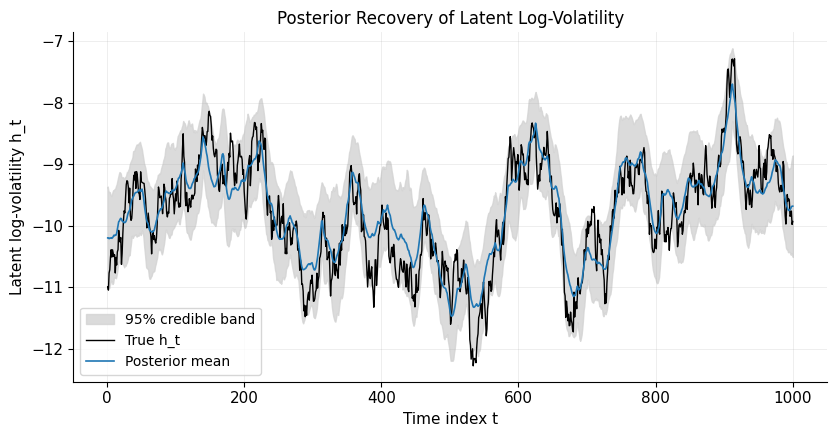

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.fill_between(
    data['time'],
    posterior_lower,
    posterior_upper,
    color='lightgray',
    alpha=0.8,
    label='95% credible band',
)
ax.plot(data['time'], data['h_true'], color='black', linewidth=1.0, label='True h_t')
ax.plot(data['time'], posterior_mean, color='#1f77b4', linewidth=1.2, label='Posterior mean')
ax.set_title('Posterior Recovery of Latent Log-Volatility')
ax.set_xlabel('Time index t')
ax.set_ylabel('Latent log-volatility h_t')
ax.legend(loc='best')
figure_files.extend(save_and_show(fig, 'fig_A4_posterior_credible_bands'))

## MCMC Diagnostics

The diagnostics below are basic checks of the sampled latent states. The trace plot shows posterior draws after burn-in for selected states, and the autocorrelation plot focuses on `h_500`.

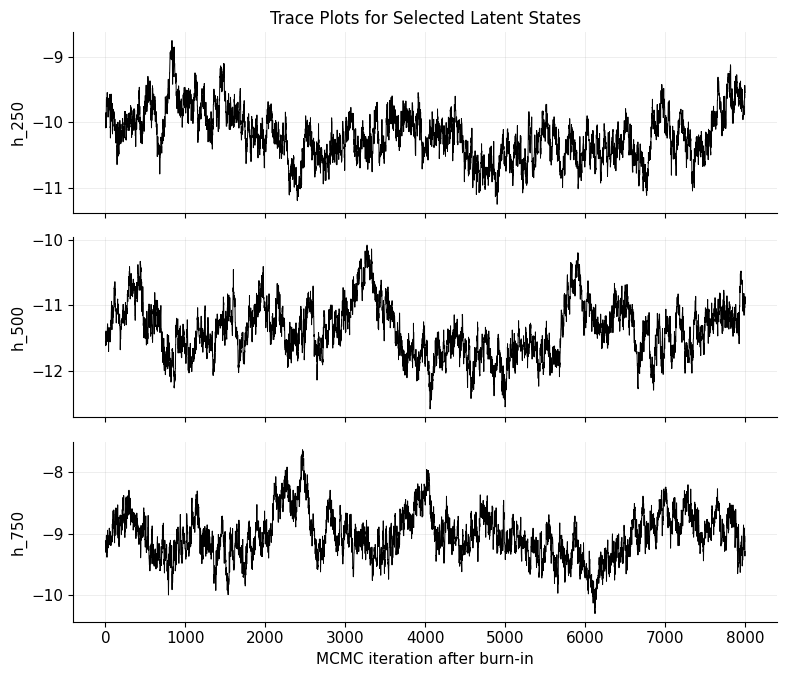

In [11]:
selected_traces = mcmc['selected_traces']
n_traces = len(selected_traces)
fig, axes = plt.subplots(n_traces, 1, figsize=(8.0, 2.3 * n_traces), sharex=True)
if n_traces == 1:
    axes = [axes]

for ax, (label, trace) in zip(axes, selected_traces.items()):
    x = np.arange(1, len(trace) + 1)
    ax.plot(x, trace, color='black', linewidth=0.7)
    ax.set_ylabel(label)

axes[0].set_title('Trace Plots for Selected Latent States')
axes[-1].set_xlabel('MCMC iteration after burn-in')
figure_files.extend(save_and_show(fig, 'fig_A5_trace_plots'))

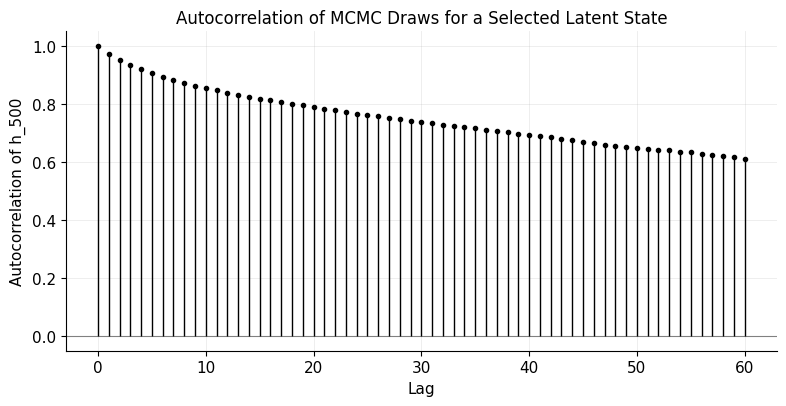

In [12]:
def autocorrelation(x, max_lag=60):
    """Compute sample autocorrelations from lag 0 through max_lag."""
    x = np.asarray(x, dtype=float)
    x_centered = x - x.mean()
    denominator = np.dot(x_centered, x_centered)

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0
    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(x_centered[:-lag], x_centered[lag:]) / denominator
    return acf


acf_label = 'h_500'
acf_trace = selected_traces[acf_label]
acf_values = autocorrelation(acf_trace, max_lag=60)
lags = np.arange(len(acf_values))

fig, ax = plt.subplots()
ax.axhline(0.0, color='gray', linewidth=0.8)
ax.vlines(lags, 0.0, acf_values, color='black', linewidth=1.0)
ax.plot(lags, acf_values, 'o', color='black', markersize=3)
ax.set_title('Autocorrelation of MCMC Draws for a Selected Latent State')
ax.set_xlabel('Lag')
ax.set_ylabel(f'Autocorrelation of {acf_label}')
figure_files.extend(save_and_show(fig, 'fig_A6_autocorrelation'))

## Numerical Summary

The final numerical summary reports the acceptance rate, posterior summaries for `h_500`, and the average width of the pointwise 95% credible intervals. The same information is also saved to the `output` folder.

In [13]:
selected_idx = 499
selected_label = f'h_{selected_idx + 1}'
selected_trace = draws[:, selected_idx]
average_ci_width = np.mean(posterior_upper - posterior_lower)

summary_lines = [
    f"Overall acceptance rate: {mcmc['acceptance_rate']:.4f}",
    f"Posterior mean of {selected_label}: {selected_trace.mean():.4f}",
    f"Posterior standard deviation of {selected_label}: {selected_trace.std(ddof=1):.4f}",
    f"Average 95% credible interval width: {average_ci_width:.4f}",
]

acceptance_path = OUTPUT_DIR / 'acceptance_rate.txt'
acceptance_path.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')

selected_summary_path = OUTPUT_DIR / 'selected_posterior_summary.csv'
with selected_summary_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(
        file,
        fieldnames=['state', 'posterior_mean', 'posterior_sd', 'q_2_5', 'q_97_5'],
    )
    writer.writeheader()
    for idx in mcmc['selected_indices']:
        trace = draws[:, idx]
        writer.writerow(
            {
                'state': f'h_{idx + 1}',
                'posterior_mean': trace.mean(),
                'posterior_sd': trace.std(ddof=1),
                'q_2_5': np.quantile(trace, 0.025),
                'q_97_5': np.quantile(trace, 0.975),
            }
        )

for line in summary_lines:
    print(line)


Overall acceptance rate: 0.6908
Posterior mean of h_500: -11.3749
Posterior standard deviation of h_500: 0.4055
Average 95% credible interval width: 1.4467
